In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
t = pd.read_csv('tariffs.csv')
t

,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name
0,50,15360,500,550,200,3,3,smart
1,1000,30720,3000,1950,150,1,1,ultra


In [3]:
c = pd.read_csv('calls.csv')
c

,id,call_date,duration,user_id
0,1000_0,2018-07-25,0.00,1000
1,1000_1,2018-08-17,0.00,1000
2,1000_2,2018-06-11,2.85,1000
3,1000_3,2018-09-21,13.80,1000
4,1000_4,2018-12-15,5.18,1000
...,...,...,...,...
202602,1499_215,2018-12-26,0.76,1499
202603,1499_216,2018-10-18,18.83,1499
202604,1499_217,2018-11-10,10.81,1499
202605,1499_218,2018-10-06,4.27,1499


In [4]:
c.columns = ['call_id', 'call_date', 'duration', 'user_id']

In [5]:
i = pd.read_csv('internet.csv')
i

,Unnamed: 0,id,mb_used,session_date,user_id
0,0,1000_0,112.95,2018-11-25,1000
1,1,1000_1,1052.81,2018-09-07,1000
2,2,1000_2,1197.26,2018-06-25,1000
3,3,1000_3,550.27,2018-08-22,1000
4,4,1000_4,302.56,2018-09-24,1000
...,...,...,...,...,...
149391,149391,1499_152,318.90,2018-10-03,1499
149392,149392,1499_153,490.13,2018-12-14,1499
149393,149393,1499_154,0.00,2018-10-27,1499
149394,149394,1499_155,1246.32,2018-11-26,1499


In [6]:
i = i.drop('Unnamed: 0', axis=1)

In [7]:
i.columns = ['internet_id', 'mb_used', 'session_date', 'user_id']

In [8]:
m = pd.read_csv('messages.csv')
m

,id,message_date,user_id
0,1000_0,2018-06-27,1000
1,1000_1,2018-10-08,1000
2,1000_2,2018-08-04,1000
3,1000_3,2018-06-16,1000
4,1000_4,2018-12-05,1000
...,...,...,...
123031,1499_179,2018-12-12,1499
123032,1499_180,2018-09-28,1499
123033,1499_181,2018-09-27,1499
123034,1499_182,2018-11-15,1499


In [9]:
m.columns = ['message_id', 'message_date', 'user_id']

In [10]:
u = pd.read_csv('users.csv')
u

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra
...,...,...,...,...,...,...,...,...
495,1495,65,NaN,Иркутск,Авксентий,Фокин,2018-08-28,ultra
496,1496,36,NaN,Вологда,Трифон,Блохин,2018-01-27,smart
497,1497,32,NaN,Челябинск,Каролина,Агеева,2018-10-09,smart
498,1498,68,2018-10-25,Владикавказ,Всеволод,Акимчин,2018-07-19,smart


In [11]:
u.isnull().sum() / len(u) * 100

user_id        0.0
age            0.0
churn_date    92.4
city           0.0
first_name     0.0
last_name      0.0
reg_date       0.0
tariff         0.0
dtype: float64

**Ушли лишь 7,6% клиентов**

In [12]:
u[u['churn_date'].isnull() == False]

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
19,1019,63,2018-10-05,Томск,Игнатий,Круглов,2018-05-16,ultra
20,1020,59,2018-12-18,Чита,Тала,Костина,2018-10-22,smart
34,1034,66,2018-11-21,Вологда,Святослав,Бондарев,2018-08-26,smart
50,1050,44,2018-10-03,Тюмень,Рузана,Аничкина,2018-06-16,ultra
51,1051,37,2018-10-14,Москва,Кристина,Сомова,2018-05-28,smart
56,1056,73,2018-10-14,Иркутск,Радислав,Артемьев,2018-04-13,smart
62,1062,24,2018-12-09,Москва,Александр,Коршунов,2018-11-16,smart
63,1063,45,2018-12-11,Тула,Таира,Климова,2018-04-12,ultra
64,1064,55,2018-12-26,Якутск,Динара,Алфеева,2018-03-17,smart
65,1065,53,2018-12-09,Москва,Роза,Игнатова,2018-03-08,smart


In [13]:
u[u['churn_date'].isnull() == False].groupby('tariff').count()['user_id']

tariff
smart    23
ultra    15
Name: user_id, dtype: int64

**Объединю таблицу пользователей с данными об их активности**

In [14]:
dfm = u.merge(m,on='user_id')
dfm

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,message_id,message_date
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_0,2018-06-27
1,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_1,2018-10-08
2,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_2,2018-08-04
3,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_3,2018-06-16
4,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_4,2018-12-05
...,...,...,...,...,...,...,...,...,...,...
123031,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_179,2018-12-12
123032,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_180,2018-09-28
123033,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_181,2018-09-27
123034,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_182,2018-11-15


In [15]:
dfc = u.merge(c,on='user_id')
dfc

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,call_id,call_date,duration
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_0,2018-07-25,0.00
1,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_1,2018-08-17,0.00
2,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_2,2018-06-11,2.85
3,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_3,2018-09-21,13.80
4,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_4,2018-12-15,5.18
...,...,...,...,...,...,...,...,...,...,...,...
202602,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_215,2018-12-26,0.76
202603,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_216,2018-10-18,18.83
202604,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_217,2018-11-10,10.81
202605,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_218,2018-10-06,4.27


In [16]:
dfi = u.merge(i,on='user_id')
dfi

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,internet_id,mb_used,session_date
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_0,112.95,2018-11-25
1,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_1,1052.81,2018-09-07
2,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_2,1197.26,2018-06-25
3,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_3,550.27,2018-08-22
4,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_4,302.56,2018-09-24
...,...,...,...,...,...,...,...,...,...,...,...
149391,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_152,318.90,2018-10-03
149392,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_153,490.13,2018-12-14
149393,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_154,0.00,2018-10-27
149394,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_155,1246.32,2018-11-26


**Посмотрю статистику по активности клиентов**

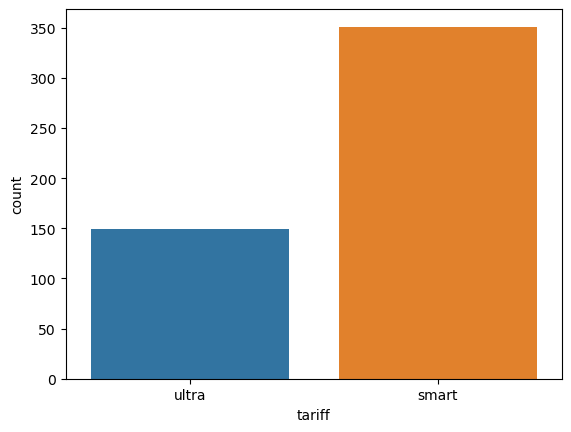

In [17]:
sns.countplot(data=u,x='tariff');

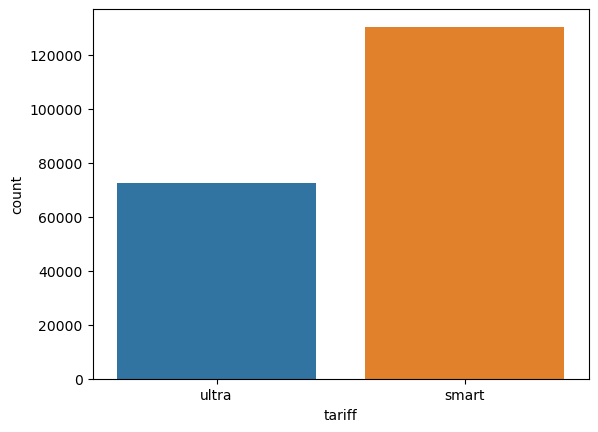

In [18]:
sns.countplot(data=dfc,x='tariff');

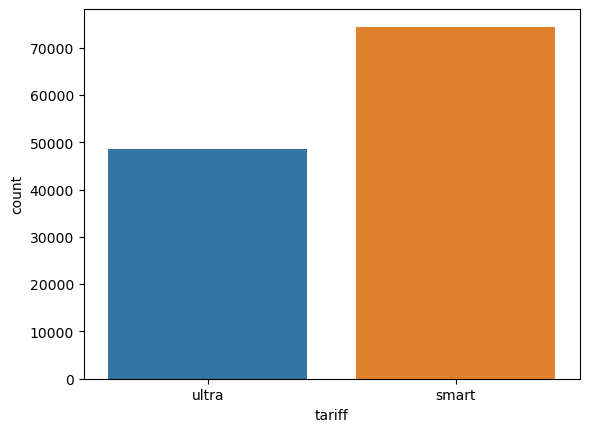

In [19]:
sns.countplot(data=dfm,x='tariff');

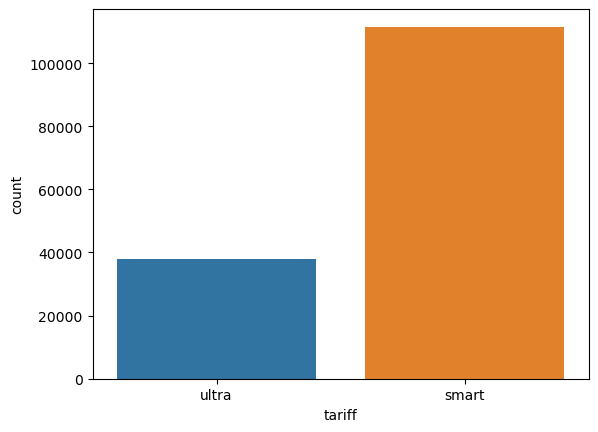

In [20]:
sns.countplot(data=dfi,x='tariff');

In [21]:
print(len(m),'сообщений')
print(len(c),'звонков')
print(len(i),'интернет-сессий')

123036 сообщений
202607 звонков
149396 интернет-сессий


In [22]:
t.columns = ['messages_included', 'mb_per_month_included', 'minutes_included',
       'rub_monthly_fee', 'rub_per_gb', 'rub_per_message', 'rub_per_minute',
       'tariff']
t

,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff
0,50,15360,500,550,200,3,3,smart
1,1000,30720,3000,1950,150,1,1,ultra


In [23]:
dfm

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,message_id,message_date
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_0,2018-06-27
1,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_1,2018-10-08
2,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_2,2018-08-04
3,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_3,2018-06-16
4,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_4,2018-12-05
...,...,...,...,...,...,...,...,...,...,...
123031,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_179,2018-12-12
123032,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_180,2018-09-28
123033,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_181,2018-09-27
123034,1499,35,NaN,Пермь,Гектор,Корнилов,2018-09-27,smart,1499_182,2018-11-15


**Объединю таблицы с нужной информацией по тарифам**

In [24]:
u = u.merge(t, on='tariff').drop(['minutes_included', 'messages_included', 'mb_per_month_included', 'rub_per_gb', 'rub_per_minute', 'rub_per_message'], axis=1)

In [25]:
dfm = dfm.merge(t, on='tariff').drop(['mb_per_month_included', 'minutes_included', 'rub_per_gb', 'rub_per_minute'], axis=1)

In [26]:
dfc = dfc.merge(t, on='tariff').drop(['mb_per_month_included', 'messages_included', 'rub_per_gb', 'rub_per_message'], axis=1)

In [27]:
dfi = dfi.merge(t, on='tariff').drop(['minutes_included', 'messages_included', 'rub_per_minute', 'rub_per_message'], axis=1)

In [28]:
dfm.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,message_id,message_date,messages_included,rub_monthly_fee,rub_per_message
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_0,2018-06-27,1000,1950,1
1,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_1,2018-10-08,1000,1950,1
2,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_2,2018-08-04,1000,1950,1
3,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_3,2018-06-16,1000,1950,1
4,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_4,2018-12-05,1000,1950,1


In [29]:
dfc.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,call_id,call_date,duration,minutes_included,rub_monthly_fee,rub_per_minute
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_0,2018-07-25,0.00,3000,1950,1
1,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_1,2018-08-17,0.00,3000,1950,1
2,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_2,2018-06-11,2.85,3000,1950,1
3,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_3,2018-09-21,13.80,3000,1950,1
4,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_4,2018-12-15,5.18,3000,1950,1


In [30]:
dfi.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,internet_id,mb_used,session_date,mb_per_month_included,rub_monthly_fee,rub_per_gb
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_0,112.95,2018-11-25,30720,1950,150
1,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_1,1052.81,2018-09-07,30720,1950,150
2,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_2,1197.26,2018-06-25,30720,1950,150
3,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_3,550.27,2018-08-22,30720,1950,150
4,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000_4,302.56,2018-09-24,30720,1950,150


**Проведу примитивный расчёт того, сколько заплатили клиенты, если учитывать только стоимость тарифа**

In [31]:
len(u[u['tariff'] == 'smart']) * 550

193050

In [32]:
len(u[u['tariff'] == 'ultra']) * 1950

290550

**Сделаю массивы с данными о том, как каждый пользователь пользовался услугами тарифа (сколько отправил сообщений, провёл минут за звонками, потратил мегабайт интернета)**

In [33]:
p_mes = dfm.groupby('user_id').count()['message_id']
p_mes

user_id
1000     496
1002      70
1003     380
1004    1192
1005     552
        ... 
1495     340
1496     468
1497      51
1498     168
1499     184
Name: message_id, Length: 426, dtype: int64

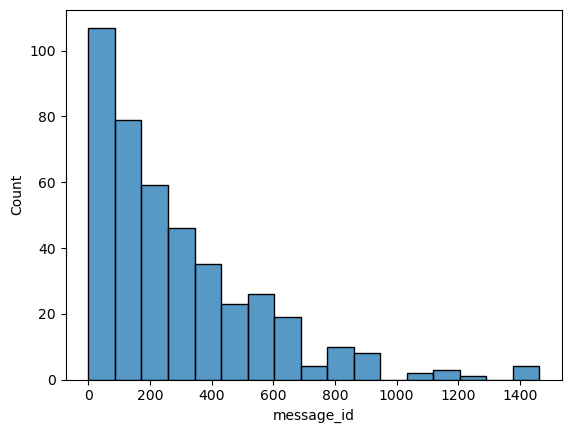

In [34]:
sns.histplot(p_mes);

In [35]:
p_cal = dfc.groupby('user_id').sum()['duration']
p_cal

user_id
1000    2418.24
1001     799.46
1002    1431.17
1003    3600.52
1004     921.21
         ...   
1495    3688.57
1496    5661.37
1497    1324.68
1498    1221.60
1499    1536.22
Name: duration, Length: 492, dtype: float64

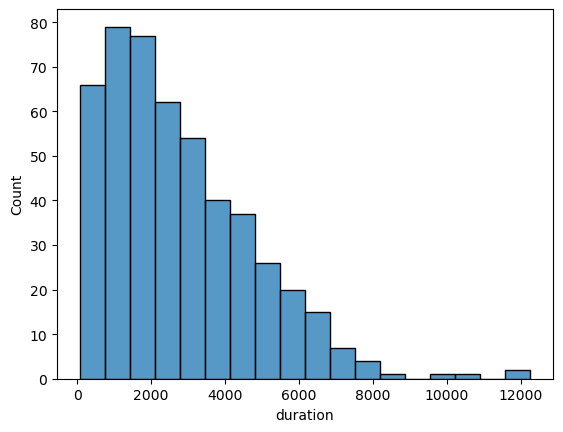

In [36]:
sns.histplot(p_cal);

In [37]:
p_int = dfi.groupby('user_id').sum()['mb_used']
p_int

user_id
1000    107392.31
1001     32466.00
1002    116036.52
1003     57280.64
1004    149039.48
          ...    
1495    127410.56
1496    270942.29
1497     45574.97
1498     74425.22
1499     50653.15
Name: mb_used, Length: 497, dtype: float64

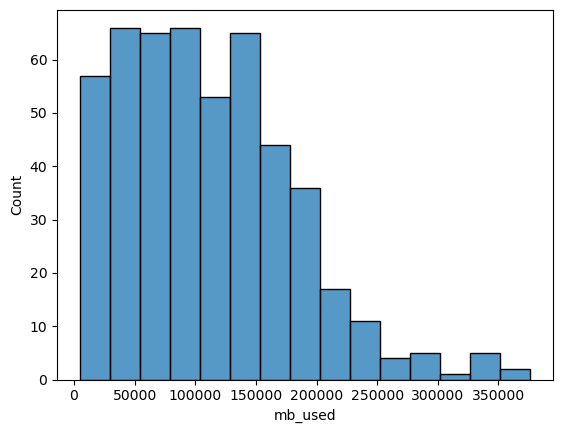

In [38]:
sns.histplot(p_int);

In [39]:
u.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,rub_monthly_fee
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1950
1,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra,1950
2,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,1950
3,1013,36,NaN,Иваново,Борис,Андреенко,2018-11-14,ultra,1950
4,1016,58,NaN,Омск,Марица,Сазонова,2018-11-21,ultra,1950


In [40]:
t

,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff
0,50,15360,500,550,200,3,3,smart
1,1000,30720,3000,1950,150,1,1,ultra


**Сделаю цикл, который посчитает, сколько денег потратил каждый пользователь в зависимости от его подписки** 

In [41]:
p_mes = u.merge(p_mes,how='left',on='user_id').fillna(0).set_index('user_id')['message_id']
p_cal = u.merge(p_cal,how='left',on='user_id').fillna(0).set_index('user_id')['duration']
p_int = u.merge(p_int,how='left',on='user_id').fillna(0).set_index('user_id')['mb_used']
counter = 0
val = []

for i in range(len(u)):
    summ = 0 
    if u['tariff'].iloc[i] == 'smart':
        if p_mes.iloc[i] > 50:
            summ += (p_mes.iloc[i] - 50) * 3
        if p_cal.iloc[i] > 500:
            summ += (p_cal.iloc[i] - 500) * 3
        if p_int.iloc[i] > 15360:
            summ += (p_int.iloc[i] - 15360) * 0.2
    else:
        if p_mes.iloc[i] > 1000:
            summ += (p_mes.iloc[i] - 1000) * 1
        if p_cal.iloc[i] > 3000:
            summ += (p_cal.iloc[i] - 3000) * 1
        if p_int.iloc[i] > 30720:
            summ += (p_int.iloc[i] - 30720) * 0.15       

    summ += u.iloc[i]['rub_monthly_fee']
    print(f'{counter}: {np.round(summ, 2)}')
    counter+=1
    val.append(int(np.round(summ, 0)))

0: 13450.85
1: 6534.62
2: 19889.92
3: 1950
4: 1950
5: 9360.32
6: 11664.42
7: 28354.36
8: 9696.85
9: 5821.82
10: 18702.41
11: 3512.55
12: 11767.85
13: 12485.4
14: 5203.54
15: 28985.36
16: 5837.74
17: 23813.28
18: 24423.43
19: 2515.08
20: 24253.03
21: 1950
22: 10014.99
23: 24824.86
24: 2841.15
25: 13452.74
26: 21046.68
27: 11818.4
28: 7393.47
29: 22348.16
30: 23621.15
31: 20766.59
32: 14802.01
33: 1950
34: 18132.36
35: 46620.87
36: 1950
37: 25674.28
38: 45332.98
39: 9996.6
40: 1950
41: 37214.93
42: 1950
43: 11739.03
44: 4865.89
45: 6680.67
46: 55920.51
47: 49573.68
48: 10243.35
49: 52603.59
50: 1950
51: 31262.19
52: 21074.74
53: 3444.32
54: 11985.88
55: 22424.67
56: 13188.45
57: 24839.68
58: 9616.71
59: 31105.26
60: 1950
61: 54696.44
62: 25804.88
63: 4720.01
64: 11327.26
65: 23796.07
66: 34921.05
67: 20496.23
68: 1950
69: 16146.04
70: 7248.11
71: 10778.8
72: 11356.09
73: 1950
74: 11174.67
75: 26717.62
76: 16571.23
77: 7667.48
78: 47620.44
79: 34685.41
80: 26531.91
81: 15003.09
82: 8881.0

**Соберу из всего этого датафрейм, чтобы можно было выполнить дальнейший анализ результатов**

In [42]:
u_val = val[:149]
s_val = val[149:]

In [43]:
vals = pd.DataFrame(u_val)

In [44]:
vals['Тариф'] = 'ultra'
vals.columns = ['Сумма', 'Тариф']
vals

,Сумма,Тариф
0,13451,ultra
1,6535,ultra
2,19890,ultra
3,1950,ultra
4,1950,ultra
...,...,...
144,20861,ultra
145,1950,ultra
146,22911,ultra
147,5505,ultra


In [45]:
valss = pd.DataFrame(s_val)
valss['Тариф'] = 'smart'
valss.columns = ['Сумма', 'Тариф']
valss

,Сумма,Тариф
0,4870,smart
1,23539,smart
2,36149,smart
3,38684,smart
4,35247,smart
...,...,...
346,16858,smart
347,68405,smart
348,9070,smart
349,14882,smart


In [46]:
vals = pd.concat([vals, valss], axis=0)
vals

,Сумма,Тариф
0,13451,ultra
1,6535,ultra
2,19890,ultra
3,1950,ultra
4,1950,ultra
...,...,...
346,16858,smart
347,68405,smart
348,9070,smart
349,14882,smart


**Средние траты клиента в зависимости от его тарифа:**

In [47]:
vals.groupby('Тариф').mean()

,Сумма
Тариф,
smart,24663.737892
ultra,18061.402685


**Распределение трат клиентов в зависимости от их тарифа:**

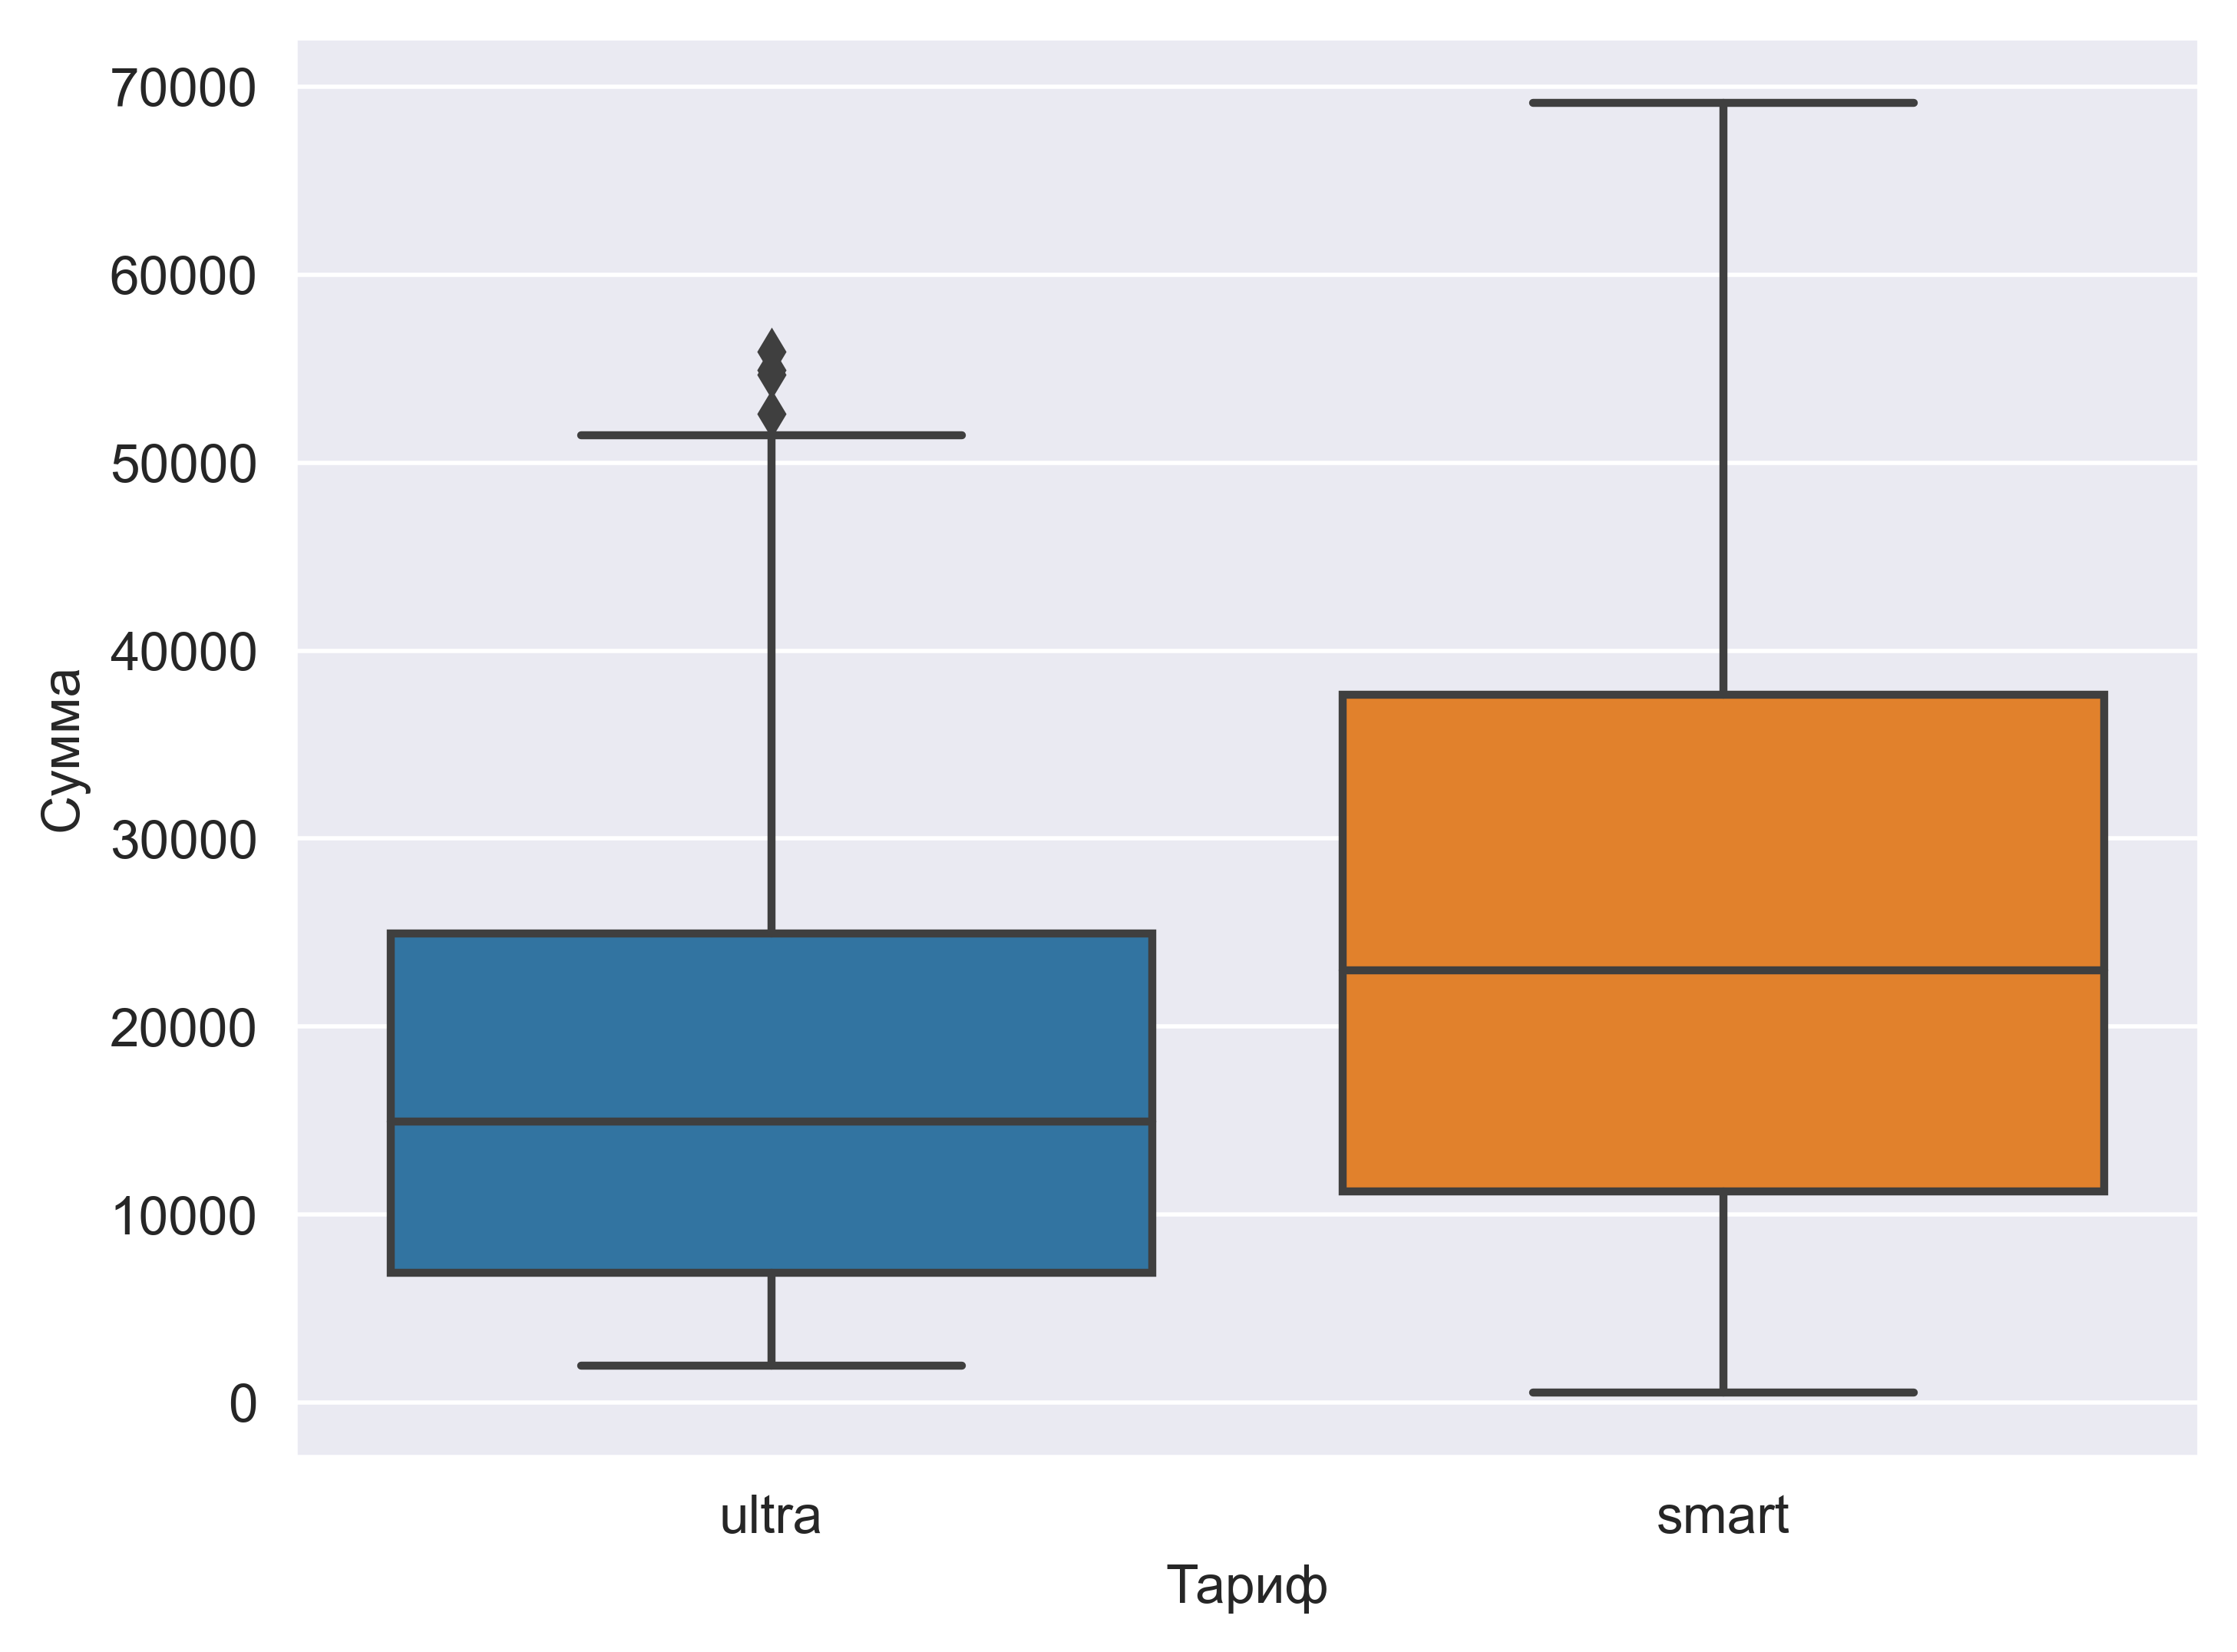

In [48]:
plt.figure(dpi=500)
sns.set_style('darkgrid')
sns.boxplot(data=vals, x='Тариф', y='Сумма');

**По распределению видно, что пользователи ДЕШЕВОГО тарифа в среднем платят БОЛЬШЕ денег**

In [49]:
vals.groupby('Тариф').sum()

,Сумма
Тариф,
smart,8656972
ultra,2691149


## Тариф smart приносит компании существенно большую прибыль

In [50]:
dfm.groupby('tariff').count()['message_id']

tariff
smart    74413
ultra    48623
Name: message_id, dtype: int64

In [51]:
dfc.groupby('tariff').sum()['duration']

tariff
smart    879177.84
ultra    489612.20
Name: duration, dtype: float64

In [52]:
dfi.groupby('tariff').sum()['mb_used']

tariff
smart    36128494.60
ultra    19176773.13
Name: mb_used, dtype: float64